# Burn severity workflow
version 8

this notebook takes a file containing one or more burn extent polygons and perfoms the burn severity workflow on them. the out put is either single files per polygon or if desiered one merged geojson for all input polygons

note: combining the results of more that roughly 50 fires into one geojson results in a very large file that is more or less unuseable with a desktop computer and this is not adviseable. 

In [ ]:
import datacube
import geopandas as gpd
from datacube.utils.cog import write_cog
import os
from datetime import date, timedelta

from dea_burn_severity.burn_severity_config import RuntimeBurnConfig


# TODO Cate - you can set the DB credentials in here
config = RuntimeBurnConfig(
    # db_name="fire_severity_product",
    # db_host="db-aurora-dea-fire-severity.cluster-cxhoeczwhtar.ap-southeast-2.rds.amazonaws.com",
    # db_user="",
    # db_password="",
)


In [ ]:
# dc = datacube.Datacube(app="Burn_severity")``

# enter username and password
for connection to database 
(do not save this to github please)

In [ ]:
# TODO Cate - no longer needed, do it in the config above
# username = ""
# password = ""

## Before we run the code set up out-put locations and file formats

define the folder location where the output polygons will be saved

for locations on your scratch space you don't need to include '/home/jovyan/' in the address

In [ ]:
# TODO Cate - no longer needed, do it in the config above
# output_folder = 'results'
# #change this path if you are saving in a different location.

# file_format = 'geojson'
# #be default the files are saved as geojsons


## Define input file

this is the file containing the burn extent polygons you wish to perform burn severity mapping on. Ic can be located in the 'gdata1' share drive or on your own scratch space. by default it is pointing at the 'early cut' of polygons provided by Aurora. 

Any (vector) file format will work, Esri Shapefile, geojson, json, geopackage

(if you are using an esri shapefile they come in four seperate file parts; .cpg, .dbf, .prj, .shp. all parts need to sit in the same folder but you point the script at the '.shp' part )


In [2]:
from dea_burn_severity.database import InputDatabase

# TODO Cate - These are defined in the configuration, if they need to be user overrideable, let me know
# db_table = 'nli_lastboundaries_trigger'
# db_columns = [
#     "fire_id",
#     "fire_name",
#     "fire_type",
#     "ignition_date",
#     "capt_date",
#     "capt_method",
#     "area_ha",
#     "perim_km",
#     "state",
#     "agency",
#     "date_retrieved",
#     "date_processed"
# ]

# app_name = 'Burn_Severity'

database = InputDatabase(config)

# TODO Cate - you could call database.load_filtered_polygons() if you don't need the intermediate bits, it runs perform_pre_filter for you.
all_boundaries_in_database = database.load_polygons_from_database()

Querying polygons from table 'Identifier('public', 'nli_lastboundaries_trigger')'...
Retrieved 5427 rows from database.


In [ ]:
all_boundaries_in_database

,fire_id,fire_name,fire_type,ignition_date,capt_date,capt_method,area_ha,perim_km,state,agency,date_retrieved,date_processed,geometry
0,102636004,Tallandoon - Yabba Road,Current Burnt Area,2025-11-01,2025-11-03,Satellite Imagery Sentinel,7.8400000000,2.3300000000,VIC,"Vic Department of Energy, Environment and Clim...",2025-11-04,2025-11-11,"MULTIPOLYGON (((147.25051 -36.42283, 147.25047..."
1,629044,"CRESCENT HEAD RD, CRESCENT HEAD",Bushfire,NaT,2025-11-04,None,2.6900000000,0.7900000000,NSW,Rural Fire Service,2025-11-04,2025-11-11,"MULTIPOLYGON (((152.93944 -31.16917, 152.93941..."
2,2b163b9b-2997-4a2e-bb90-30638dbe3ab3,None,None,2025-11-03,2025-11-03,FIREMAPPER,20370.9100000000,137.5000000000,QLD,Qld Fire and Emergency Services,2025-11-04,2025-11-11,"POLYGON ((150.55255 -27.88581, 150.55268 -27.8..."
3,e6e34de9-6158-4ee7-9024-eae94b80c422,None,None,2025-10-29,2025-11-02,FIREMAPPER,1442.6000000000,20.3600000000,QLD,Qld Fire and Emergency Services,2025-11-03,2025-11-11,"POLYGON ((142.79364 -18.38440, 142.79364 -18.3..."
4,243646,Unnamed Fire - 243646,Current Burnt Area,2025-11-02,2025-11-02,Field Intelligence Field Intelligence and Fire...,58.3600000000,3.7500000000,VIC,Vic Country Fire Authority,2025-11-03,2025-11-11,"MULTIPOLYGON (((143.53699 -35.62578, 143.53677..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5422,250805,Unnamed Fire - 250805,Current Burnt Area,2025-12-20,2025-12-20,Satellite Imagery Sentinel,3.3000000000,0.7800000000,VIC,Vic Country Fire Authority,2025-12-21,2026-03-22,"MULTIPOLYGON (((144.28039 -36.48760, 144.27936..."
5423,637787,Bramina Creek,Bushfire,NaT,2025-12-20,None,0.3300000000,0.2300000000,NSW,Forestry Corporation of NSW,2025-12-21,2026-03-22,"MULTIPOLYGON (((148.62468 -35.40538, 148.62468..."
5424,649326,"DEMAMIEL RD, WHITTON",Bushfire,NaT,2026-03-11,None,0.7000000000,0.3500000000,NSW,NSW National Parks and Wildlife Service,2026-03-11,2026-03-22,"MULTIPOLYGON (((146.18948 -34.61492, 146.18945..."
5425,250718,BAGSHOT - SUTTON TRACK,Current Burnt Area,2025-12-20,2025-12-20,Satellite Imagery Sentinel,0.1900000000,0.1700000000,VIC,Vic Country Fire Authority,2025-12-21,2026-03-22,"MULTIPOLYGON (((144.42402 -36.66592, 144.42401..."


In [3]:
#filter on size 
poly = all_boundaries_in_database[all_boundaries_in_database['fire_id'] == 'e6e34de9-6158-4ee7-9024-eae94b80c422']


<Axes: >

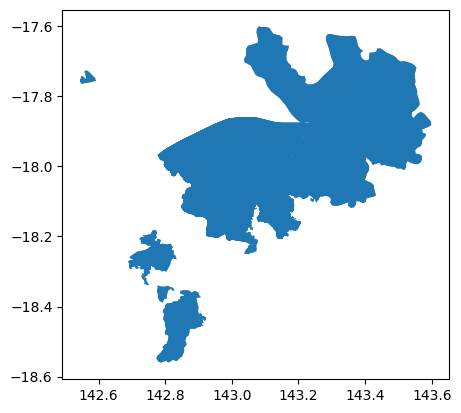

In [4]:
poly.plot()

In [ ]:
# input_file = '/home/jovyan/gdata1/projects/Hazards/burn_severity/fire_extents_2025-26_summer/all_fires_at_29JAN26.gpkg'
# #define input file

# poly = gpd.read_file(input_file)
# #open as a geopandas geodataframe and have a look at the first few rows

# #let's peek at the first one
# poly.iloc[0]

## check attributes

code asumes your input polygons have the attributes defined by the trigger product data dictionary. Shapefiles do this fun thing where they shorten long attribute names, so if you are using a shapefile we will fix that up now. 
        'fire_id',
        'fire_name',
        'fire_type',
        'ignition_date',
        'capt_date',
        'capt_method',
        'area_ha',
        'perim_km',
        'state',
        'agency'
        'date_retrieved'
        'date_processed'

if your polygon dosn't have the correct attibutes (they can be empty they just need to be there) the script will get Angry at you and not run

        

In [5]:
#test attribute format
from dea_burn_severity.burn_severity_notebook_helper import *

poly = test_polygon_attributes(all_boundaries_in_database)

attibutes are long, no need to change


In [6]:
poly

,fire_id,fire_name,fire_type,ignition_date,capt_date,capt_method,area_ha,perim_km,state,agency,date_retrieved,date_processed,geometry
0,102636004,Tallandoon - Yabba Road,Current Burnt Area,2025-11-01,2025-11-03,Satellite Imagery Sentinel,7.8400000000,2.3300000000,VIC,"Vic Department of Energy, Environment and Clim...",2025-11-04,2025-11-11,"MULTIPOLYGON (((147.25051 -36.42283, 147.25047..."
1,629044,"CRESCENT HEAD RD, CRESCENT HEAD",Bushfire,NaT,2025-11-04,None,2.6900000000,0.7900000000,NSW,Rural Fire Service,2025-11-04,2025-11-11,"MULTIPOLYGON (((152.93944 -31.16917, 152.93941..."
2,2b163b9b-2997-4a2e-bb90-30638dbe3ab3,None,None,2025-11-03,2025-11-03,FIREMAPPER,20370.9100000000,137.5000000000,QLD,Qld Fire and Emergency Services,2025-11-04,2025-11-11,"POLYGON ((150.55255 -27.88581, 150.55268 -27.8..."
3,e6e34de9-6158-4ee7-9024-eae94b80c422,None,None,2025-10-29,2025-11-02,FIREMAPPER,1442.6000000000,20.3600000000,QLD,Qld Fire and Emergency Services,2025-11-03,2025-11-11,"POLYGON ((142.79364 -18.38440, 142.79364 -18.3..."
4,243646,Unnamed Fire - 243646,Current Burnt Area,2025-11-02,2025-11-02,Field Intelligence Field Intelligence and Fire...,58.3600000000,3.7500000000,VIC,Vic Country Fire Authority,2025-11-03,2025-11-11,"MULTIPOLYGON (((143.53699 -35.62578, 143.53677..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5422,250805,Unnamed Fire - 250805,Current Burnt Area,2025-12-20,2025-12-20,Satellite Imagery Sentinel,3.3000000000,0.7800000000,VIC,Vic Country Fire Authority,2025-12-21,2026-03-22,"MULTIPOLYGON (((144.28039 -36.48760, 144.27936..."
5423,637787,Bramina Creek,Bushfire,NaT,2025-12-20,None,0.3300000000,0.2300000000,NSW,Forestry Corporation of NSW,2025-12-21,2026-03-22,"MULTIPOLYGON (((148.62468 -35.40538, 148.62468..."
5424,649326,"DEMAMIEL RD, WHITTON",Bushfire,NaT,2026-03-11,None,0.7000000000,0.3500000000,NSW,NSW National Parks and Wildlife Service,2026-03-11,2026-03-22,"MULTIPOLYGON (((146.18948 -34.61492, 146.18945..."
5425,250718,BAGSHOT - SUTTON TRACK,Current Burnt Area,2025-12-20,2025-12-20,Satellite Imagery Sentinel,0.1900000000,0.1700000000,VIC,Vic Country Fire Authority,2025-12-21,2026-03-22,"MULTIPOLYGON (((144.42402 -36.66592, 144.42401..."


## pre-filtering

pre-filtering steps on polygons:
- remove any polygons with no area or smaller than 1 ha
- check for duplicates for the same fire and perfrom spatial join on them


In [7]:
# TODO Cate - you can set the minimum area in the config object
mature_fires = database.perform_pre_filter(all_boundaries_in_database)

# #filter on size 
# poly = poly.drop(poly[poly.area_ha < 1].index)

# #list all fire 'id' names
# list_of_fires = list(set(poly['fire_id']))

# #perform spatial dissolve on overlapping polygons with same id
# dissolved_duplicates = perform_spatial_dissolve(poly, list_of_fires)

Started with: 5427
After removing small entries (<1ha): 4526
After removing invalid entries: 4019
After dissolving overlapping entries: 1608
After removing fires processed <60 days ago: 625


/home/ubuntu/repos/dea-burn-severity/src/dea_burn_severity/database.py:237: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  filtered = filtered.fillna(0)


In [8]:
mature_fires.iloc[0]

geometry          POLYGON ((148.499438706 -25.409456514, 148.499...
fire_id                        1863FE9D-852C-4B7F-98B2-A155CE0BD1DD
fire_name                                                         0
fire_type                                                         0
capt_method                                                    MICA
area_ha                                              434.4200000000
perim_km                                               9.3100000000
state                                                           QLD
agency                              Qld Fire and Emergency Services
date_retrieved                                  2025-10-20 00:00:00
ignition_date                                   2025-10-07 00:00:00
capt_date                                       2025-10-07 00:00:00
date_processed                                           2026-01-21
Name: 1, dtype: object

## Filter by age

we only want to run our process of files older that 60 days. that is filres that have been extinguished for more than 60 days


In [ ]:
# TODO Cate - this is handled in the filter step, you can set the parameters in the config object at the top
# today_date = date.today()

# cutoff_date = today_date - timedelta(days=65)

# mature_fires = dissolved_duplicates[dissolved_duplicates.date_processed <= cutoff_date]

# #make all nan 0 to eliminate cate's date filtering headache!!
# mature_fires = mature_fires.fillna(0)

/tmp/ipykernel_137/1139670586.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mature_fires = mature_fires.fillna(0)


In [9]:
processed_dates = list(set(mature_fires['date_processed']))

In [10]:
processed_dates

[datetime.date(2026, 1, 8),
 datetime.date(2025, 12, 24),
 datetime.date(2025, 11, 30),
 datetime.date(2025, 11, 25),
 datetime.date(2025, 11, 23),
 datetime.date(2025, 12, 8),
 datetime.date(2025, 12, 16),
 datetime.date(2026, 1, 12),
 datetime.date(2025, 12, 14),
 datetime.date(2026, 1, 6),
 datetime.date(2025, 12, 28),
 datetime.date(2025, 11, 18),
 datetime.date(2025, 11, 24),
 datetime.date(2025, 11, 26),
 datetime.date(2025, 12, 9),
 datetime.date(2025, 12, 17),
 datetime.date(2025, 12, 11),
 datetime.date(2025, 11, 11),
 datetime.date(2025, 12, 13),
 datetime.date(2025, 11, 14),
 datetime.date(2025, 11, 27),
 datetime.date(2026, 1, 19),
 datetime.date(2025, 12, 7),
 datetime.date(2026, 1, 18),
 datetime.date(2026, 1, 2),
 datetime.date(2026, 1, 17),
 datetime.date(2026, 1, 11),
 datetime.date(2026, 1, 7),
 datetime.date(2025, 11, 19),
 datetime.date(2025, 12, 30),
 datetime.date(2025, 12, 1),
 datetime.date(2026, 1, 20),
 datetime.date(2025, 11, 22),
 datetime.date(2026, 1, 9),


# For NOTEBOOK USE ONLY

the next four cells further filter mature fires to process only one day at a time in order to more easily manage workload when conducting manual backfill.
this dosn't need to be copied to the pipline 

In [11]:
date_to_use = date(2025, 11, 17)
process_today = mature_fires[mature_fires['date_processed'] == date_to_use]

In [12]:
len(process_today)

2

In [ ]:
# analysis_out_folder= f'{output_folder}/{str(date_to_use)}'
# os.makedirs(analysis_out_folder, exist_ok=True)

In [ ]:
# log_file = 'results/processed_fires.txt'

## map burn severity


In [14]:

from dea_burn_severity.burn_severity_processing import BurnSeverityProcessor

burn_processing = BurnSeverityProcessor(config)
burn_processing.process_all_polygons(process_today)

# #this essentially creates a numerical list of each dissolved fire
# for fires in range(0,len(process_today.index)):

    
#     #select each polygon one-by -one
#     fire_polygon = gpd.GeoDataFrame(process_today.iloc[fires].to_frame().T, geometry='geometry', crs=process_today.crs)

#     #make a sting which is fire id and position in gpd to not over-write re-use of ids in QLD
#     fire_id_forsave = f'{fire_polygon.fire_id.iloc[0]}_{fires}'
    
#     #run burn severity mapping
#     Severity_polygons, debug_layer = map_burn_severity(fire_polygon)

#        # #save_debug layer to file
#     write_cog(debug_layer.compute(), f'{analysis_out_folder}/DEA_burn_severity_debug_{fire_id_forsave}.tif',
#              overwrite=True)

#     Severity_polygons.to_file(f'{analysis_out_folder}/DEA_burn_severity_{fire_id_forsave}.{file_format}')

#     #add index to file
    
#     text_to_add = f"({fire_polygon.fire_id.iloc[0]}, {fire_polygon.date_processed.iloc[0]}),\n"
    
#     with open(log_file, "a") as file:
#         file.write(text_to_add)

    
#     print( f'I finished processing number {fires}')
    


All outputs will be saved to: products
Found 2 total features. Processing all of them.

Beginning per-fire processing (single polygon per feature)...

Processing fire polygon: 'fire_id_2b163b9b-2997-4a2e-bb90-30638dbe3ab3'
Finding datasets
    ga_s2am_ard_3
    ga_s2bm_ard_3
    ga_s2cm_ard_3
Counting good quality pixels for each time step using s2cloudless
Filtering to 9 out of 13 time steps with at least 99.0% good quality pixels
Applying s2cloudless pixel quality/cloud mask
Returning 9 time steps as a dask array
Attempting load_ard with min_gooddata=0.9 ...
Finding datasets
    ga_s2am_ard_3
    ga_s2bm_ard_3
    ga_s2cm_ard_3
Counting good quality pixels for each time step using s2cloudless
Filtering to 11 out of 16 time steps with at least 90.0% good quality pixels
Applying s2cloudless pixel quality/cloud mask
Returning 11 time steps as a dask array
Success: Loaded 11 time slices.
Dropping bands ['nbart_blue', 'nbart_green', 'nbart_red', 'nbart_nir_1', 'nbart_nir_2', 'nbart_swir_2